<a href="https://colab.research.google.com/github/uttradewangan222-svg/CTRL-alt-Elites/blob/main/Fraud%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Payment Fraud Detection
End-to-end notebook: load data → explore → preprocess → train models → evaluate.

## 1. Load the data

In [ ]:
import pandas as pd

df = pd.read_csv('online_fraud.csv')  # adjust filename if different
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   step                  int64  
 1   type                  str    
 2   amount                float64
 3   nameOrig              str    
 4   oldbalanceOrg         float64
 5   newbalanceOrig        float64
 6   nameDest              str    
 7   oldbalanceDest        float64
 8   newbalanceDest        float64
 9   isFraud               int64  
 10  isFlaggedFraud        int64  
 11  isFullBalanceDrain    int64  
 12  amountToBalanceRatio  float64
 13  isTransferOrCashout   int64  
dtypes: float64(6), int64(5), str(3)
memory usage: 679.6 MB


In [ ]:
df.shape

(6362620, 14)

## 2. Explore the data (EDA)

In [ ]:
# Fraud class balance
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

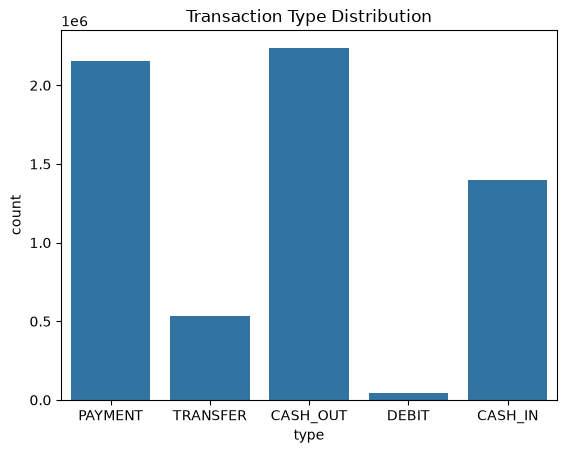

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
2,181.00,181.00,0.0,0.0,0.00
3,181.00,181.00,0.0,21182.0,0.00
251,2806.00,2806.00,0.0,0.0,0.00
252,2806.00,2806.00,0.0,26202.0,0.00
680,20128.00,20128.00,0.0,0.0,0.00
681,20128.00,20128.00,0.0,6268.0,12145.85
724,416001.33,0.00,0.0,102.0,9291619.62
969,1277212.77,1277212.77,0.0,0.0,0.00
970,1277212.77,1277212.77,0.0,0.0,2444985.19
1115,35063.63,35063.63,0.0,0.0,0.00


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title('Transaction Type Distribution')
plt.show()
df[df['isFraud'] == 1]['type'].value_counts()
df[df['isFraud'] == 1][['amount', 'oldbalanceOrg', 'newbalanceOrig',
                         'oldbalanceDest', 'newbalanceDest']].head(10)








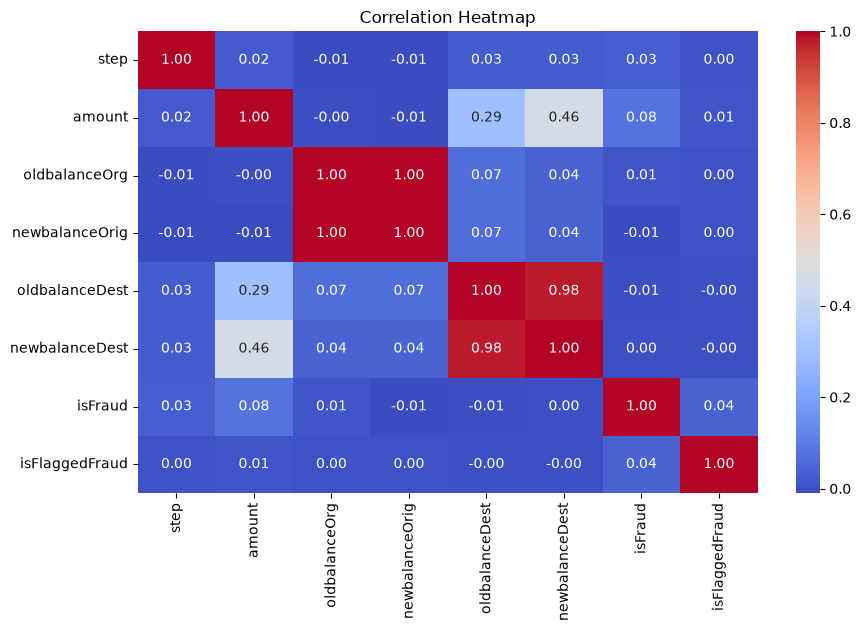

In [ ]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 3. Preprocess the data

In [ ]:
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

df_encoded = df_encoded.drop(columns=[
    'nameOrig', 'nameDest',
    'newbalanceOrig', 'newbalanceDest',   # leaky: zeroed out post-fraud
   # 'errorBalanceOrig', 'errorBalanceDest'  # derived from leaky columns, drop these too
])

df_encoded.head()


,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud,isFullBalanceDrain,amountToBalanceRatio,isTransferOrCashout,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,0.0,0,0,0,0.057834,0,False,False,True,False
1,1,1864.28,21249.0,0.0,0,0,0,0.087731,0,False,False,True,False
2,1,181.00,181.0,0.0,1,0,1,0.994505,1,False,False,False,True
3,1,181.00,181.0,21182.0,1,0,1,0.994505,1,True,False,False,False
4,1,11668.14,41554.0,0.0,0,0,0,0.280788,0,False,False,True,False


In [ ]:
# Safe feature 1: does the amount drain the entire origin balance? (classic fraud pattern)
df['isFullBalanceDrain'] = (df['amount'] == df['oldbalanceOrg']).astype(int)

# Safe feature 2: transaction amount relative to the sender's balance
df['amountToBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # +1 avoids divide-by-zero

# Safe feature 3: flag for the two fraud-prone transaction types (already validated in EDA)
df['isTransferOrCashout'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

df[['isFullBalanceDrain', 'amountToBalanceRatio', 'isTransferOrCashout']].describe()


,isFullBalanceDrain,amountToBalanceRatio,isTransferOrCashout
count,6.362620e+06,6.362620e+06,6.362620e+06
mean,1.262687e-03,7.067448e+04,4.354195e-01
std,3.551187e-02,5.084243e+05,4.958119e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.344011e-01,0.000000e+00
50%,0.000000e+00,6.453832e+00,0.000000e+00
75%,0.000000e+00,1.228776e+04,1.000000e+00
max,1.000000e+00,9.244552e+07,1.000000e+00


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['isFraud'])
y = df_encoded['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((4453834, 13), (1908786, 13))

## 4. Train models
We'll compare Logistic Regression, Random Forest, and XGBoost.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

ValueError: could not convert string to float: 'C386091144'

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

ValueError: could not convert string to float: 'C386091144'

In [ ]:
import xgboost as xgb

# Compute class imbalance ratio for scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    enable_categorical=False,   # avoid XGBoost misreading dummy/bool columns as categorical
    scale_pos_weight=scale      # tell it explicitly how rare fraud is
)
xgb_model.fit(X_train.astype(float), y_train)



















ValueError: could not convert string to float: 'C386091144'

## 5. Evaluate the models
Accuracy is misleading here since fraud is <1% of the data. We focus on ROC-AUC, precision, recall, and the confusion matrix — especially recall on the fraud class.

--- Logistic Regression ---
ROC-AUC: 0.8343552368971967
              precision    recall  f1-score   support

           0     0.9987    1.0000    0.9994   1906322
           1     0.2500    0.0020    0.0040      2464

    accuracy                         0.9987   1908786
   macro avg     0.6244    0.5010    0.5017   1908786
weighted avg     0.9977    0.9987    0.9981   1908786



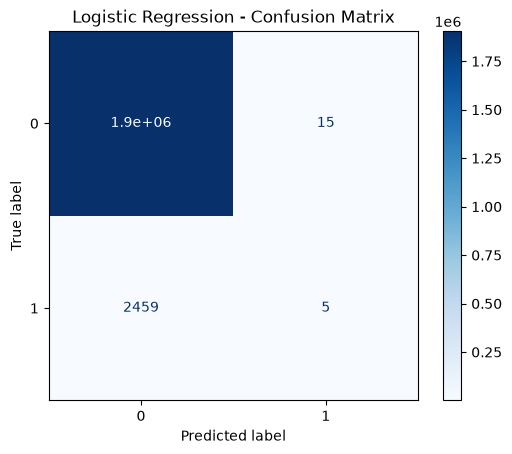

In [ ]:
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

def evaluate(model, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"--- {name} ---")
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print(classification_report(y_test, preds, digits=4))

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

evaluate(log_reg, "Logistic Regression")

--- Random Forest ---
ROC-AUC: 0.9981733305441293
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1906322
           1     1.0000    0.9963    0.9982      2464

    accuracy                         1.0000   1908786
   macro avg     1.0000    0.9982    0.9991   1908786
weighted avg     1.0000    1.0000    1.0000   1908786



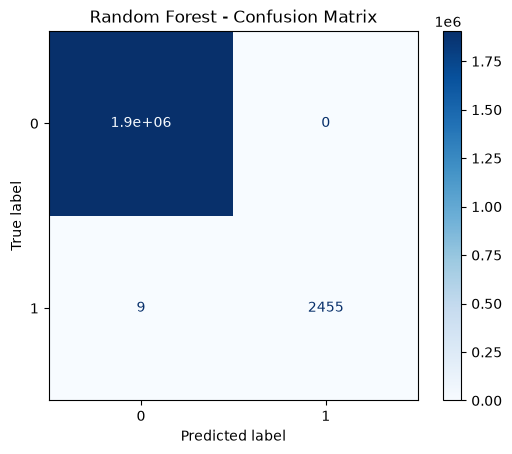

In [ ]:
evaluate(rf, "Random Forest")

--- XGBoost ---
ROC-AUC: 0.9999167314823294
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1906322
           1     0.9943    0.9963    0.9953      2464

    accuracy                         1.0000   1908786
   macro avg     0.9972    0.9982    0.9977   1908786
weighted avg     1.0000    1.0000    1.0000   1908786



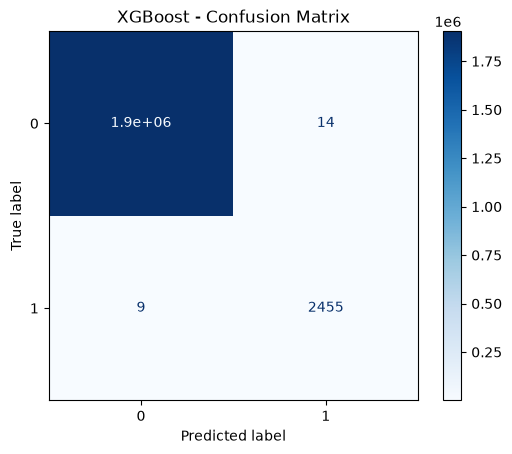

In [ ]:
evaluate(xgb_model, "XGBoost")

## 6. (Optional) Save the best model

In [ ]:
joblib.dump(rf, 'fraud_detection_model.pkl')
print("Model saved as fraud_detection_model.pkl")

Model saved as fraud_detection_model.pkl
